# XGBoost — PM2.5 Tashkent
Step-by-step: load data → train → metrics → plots → save

## 1. Imports and configuration

In [1]:
import json
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

BASE       = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR   = os.path.join(BASE, 'data')
MODELS_DIR = os.path.join(BASE, 'models')
OUT_DIR    = os.path.join(BASE, 'outputs', 'xgb_es_analysis')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUT_DIR,    exist_ok=True)

print('Ready.')
print(f'Output: {OUT_DIR}')

Ready.
Output: c:\Users\LENOVO\Desktop\Project 2.5\pm25_project\service1\outputs\xgb_es_analysis


## 2. Load data

In [2]:
train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'), parse_dates=['datetime'])
test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'),  parse_dates=['datetime'])

with open(os.path.join(DATA_DIR, 'feature_cols.json')) as f:
    feature_cols = json.load(f)

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
print(f'Features: {len(feature_cols)}')
print('\nFeature list:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:2}. {col}')

Train : (16928, 28)
Test  : (4233, 28)
Features: 25

Feature list:
   1. temperature_2m
   2. relative_humidity_2m
   3. wind_speed_10m
   4. wind_direction_10m
   5. surface_pressure
   6. precipitation
   7. pm25_lag_1h
   8. pm25_lag_2h
   9. pm25_lag_3h
  10. pm25_lag_6h
  11. pm25_lag_12h
  12. pm25_lag_24h
  13. pm25_lag_48h
  14. pm25_roll_3h
  15. pm25_roll_6h
  16. pm25_roll_24h
  17. pm25_roll_7d
  18. hour_sin
  19. hour_cos
  20. dow_sin
  21. dow_cos
  22. month_sin
  23. month_cos
  24. wind_u
  25. wind_v


## 3. Target (PM2.5) statistics

In [3]:
print('=== Train PM2.5 statistics ===')
print(train['pm25'].describe().round(2))
print('\n=== Test PM2.5 statistics ===')
print(test['pm25'].describe().round(2))

=== Train PM2.5 statistics ===
count    16928.00
mean        32.03
std         38.29
min          0.00
25%          9.30
50%         17.00
75%         38.51
max        249.21
Name: pm25, dtype: float64

=== Test PM2.5 statistics ===
count    4233.00
mean       25.23
std        25.12
min         0.25
25%        10.70
50%        16.80
75%        27.80
max       224.95
Name: pm25, dtype: float64


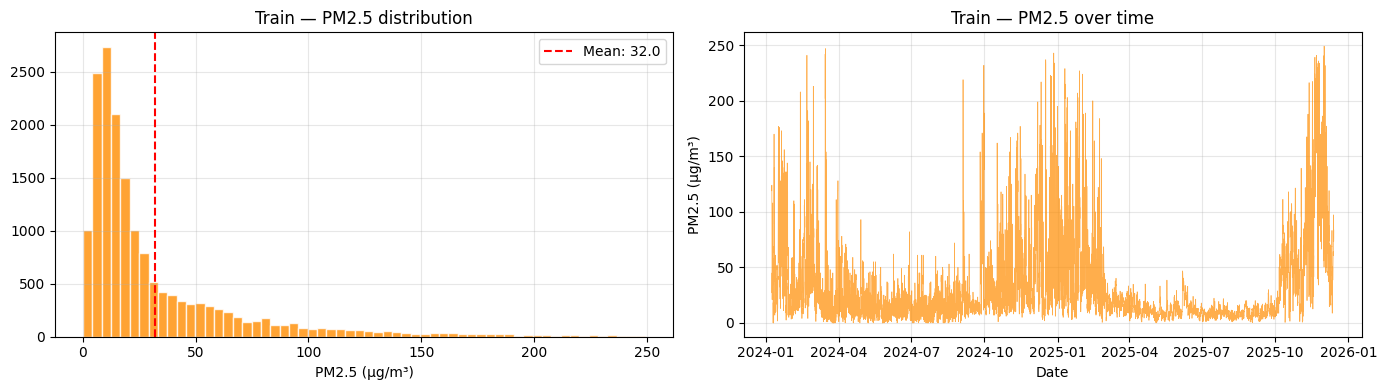

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train['pm25'], bins=60, color='darkorange', edgecolor='white', alpha=0.8)
axes[0].axvline(train['pm25'].mean(), color='red', linestyle='--',
                label=f"Mean: {train['pm25'].mean():.1f}")
axes[0].set_title('Train — PM2.5 distribution')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].legend()

axes[1].plot(train['datetime'], train['pm25'], linewidth=0.5, color='darkorange', alpha=0.7)
axes[1].set_title('Train — PM2.5 over time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '01_pm25_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Split features and target

In [7]:
X_train = train[feature_cols].values
y_train = train['pm25'].values
X_test  = test[feature_cols].values
y_test  = test['pm25'].values

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'X_train NaN: {np.isnan(X_train).sum()}')
print(f'X_test  NaN: {np.isnan(X_test).sum()}')

X_train : (16928, 25)
X_test  : (4233, 25)
X_train NaN: 0
X_test  NaN: 0


## 5. Train XGBoost

In [8]:
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric='rmse',
)

print('Training XGBoost with early stopping...')
t0 = time.time()
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)
elapsed = time.time() - t0
print(f'Done. Time: {elapsed:.1f}s')
print(f'Best round: {model.best_iteration}')
print(f'Best RMSE : {model.best_score:.4f}')

Training XGBoost with early stopping...
[0]	validation_0-rmse:24.82661
[50]	validation_0-rmse:7.60710
[100]	validation_0-rmse:7.35370
[112]	validation_0-rmse:7.39248
Done. Time: 1.0s
Best round: 92
Best RMSE : 7.3534


## 6. Training loss curve

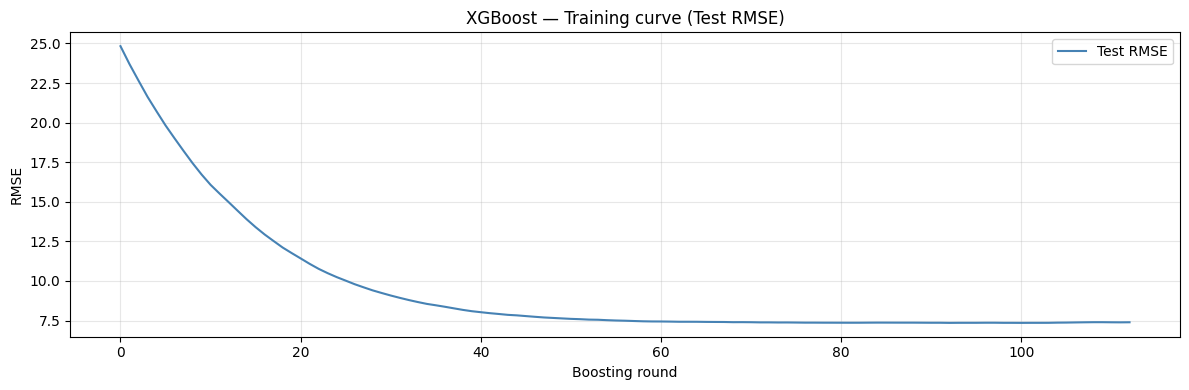

Best round     : 92
Best test RMSE : 7.353


In [9]:
results   = model.evals_result()
test_rmse = results['validation_0']['rmse']

plt.figure(figsize=(12, 4))
plt.plot(test_rmse, label='Test RMSE', color='steelblue')
plt.xlabel('Boosting round')
plt.ylabel('RMSE')
plt.title('XGBoost — Training curve (Test RMSE)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '02_training_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

best_round = int(np.argmin(test_rmse))
print(f'Best round     : {best_round}')
print(f'Best test RMSE : {min(test_rmse):.3f}')

## 7. Predictions and metrics

In [11]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train  = mean_absolute_error(y_train, y_pred_train)
r2_train   = r2_score(y_train, y_pred_train)

rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test   = mean_absolute_error(y_test, y_pred_test)
r2_test    = r2_score(y_test, y_pred_test)

print('=' * 42)
print(f'{"Metric":<12} {"Train":>12} {"Test":>12}')
print('-' * 42)
print(f'{"RMSE":<12} {rmse_train:>12.3f} {rmse_test:>12.3f}')
print(f'{"MAE":<12} {mae_train:>12.3f} {mae_test:>12.3f}')
print(f'{"R2":<12} {r2_train:>12.4f} {r2_test:>12.4f}')
print('=' * 42)

print(f'\nTarget: RMSE < 12, R2 > 0.90')
print(f'RMSE test : {rmse_test:.2f} => {"PASS" if rmse_test < 12 else "FAIL"}')
print(f'R2   test : {r2_test:.4f} => {"PASS" if r2_test > 0.90 else "FAIL"}')

Metric              Train         Test
------------------------------------------
RMSE                8.678        7.353
MAE                 4.980        3.509
R2                 0.9486       0.9143

Target: RMSE < 12, R2 > 0.90
RMSE test : 7.35 => PASS
R2   test : 0.9143 => PASS


## 8. Actual vs Predicted plots

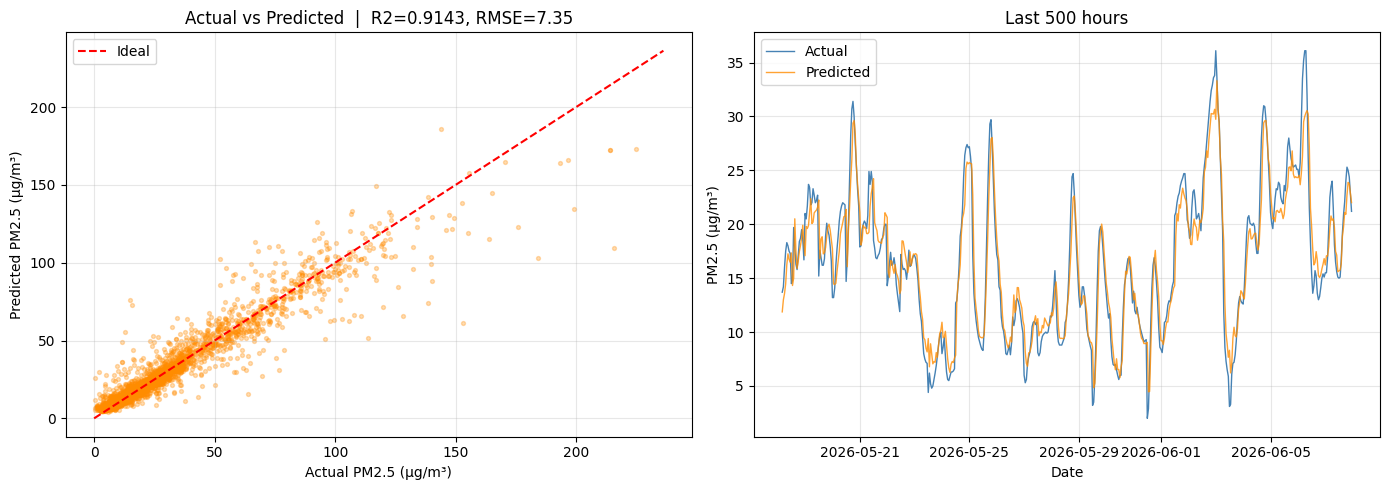

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.3, s=8, color='darkorange')
lim_max = max(y_test.max(), y_pred_test.max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], 'r--', linewidth=1.5, label='Ideal')
ax.set_xlabel('Actual PM2.5 (µg/m³)')
ax.set_ylabel('Predicted PM2.5 (µg/m³)')
ax.set_title(f'Actual vs Predicted  |  R2={r2_test:.4f}, RMSE={rmse_test:.2f}')
ax.legend()

ax = axes[1]
n = 500
dates = test['datetime'].iloc[-n:]
ax.plot(dates, y_test[-n:],      label='Actual',    linewidth=1, color='steelblue')
ax.plot(dates, y_pred_test[-n:], label='Predicted', linewidth=1, color='darkorange', alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Last 500 hours')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '03_actual_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Residuals analysis

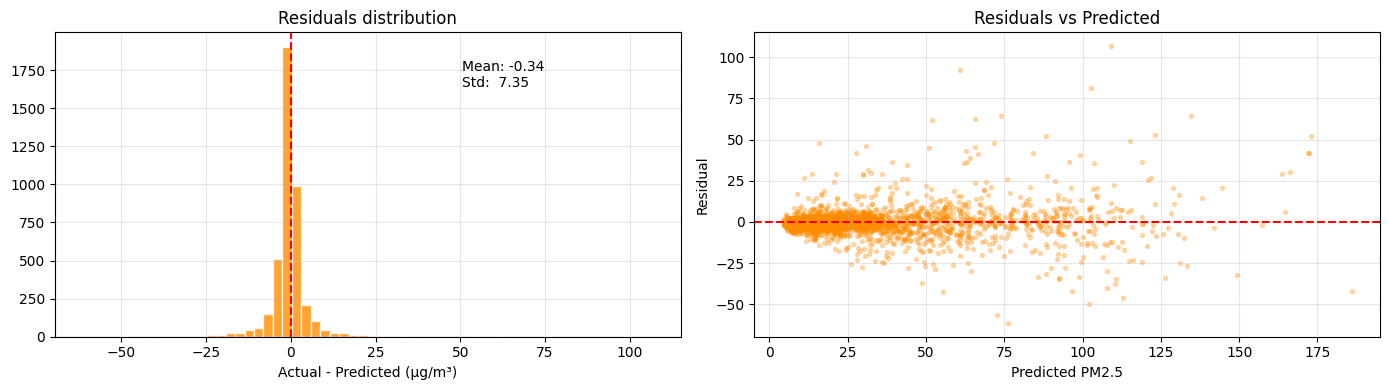

Mean : -0.338  (should be close to 0)
Std  : 7.346
Min  : -61.174
Max  : 106.600


In [13]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals, bins=60, color='darkorange', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residuals distribution')
axes[0].set_xlabel('Actual - Predicted (µg/m³)')
axes[0].annotate(f'Mean: {residuals.mean():.2f}\nStd:  {residuals.std():.2f}',
                 xy=(0.65, 0.82), xycoords='axes fraction', fontsize=10)

axes[1].scatter(y_pred_test, residuals, alpha=0.3, s=8, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted PM2.5')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean : {residuals.mean():.3f}  (should be close to 0)')
print(f'Std  : {residuals.std():.3f}')
print(f'Min  : {residuals.min():.3f}')
print(f'Max  : {residuals.max():.3f}')

## 10. Feature importance (top 15)

Top 15 features:
         feature  importance
     pm25_lag_1h    0.590241
    pm25_roll_3h    0.176787
     pm25_lag_2h    0.064688
     pm25_lag_3h    0.010852
   pm25_roll_24h    0.009823
    pm25_lag_24h    0.009482
    pm25_roll_6h    0.009382
        hour_cos    0.009209
          wind_v    0.008865
         dow_cos    0.008784
surface_pressure    0.008589
          wind_u    0.008072
        hour_sin    0.008040
    pm25_lag_12h    0.008032
       month_sin    0.007832


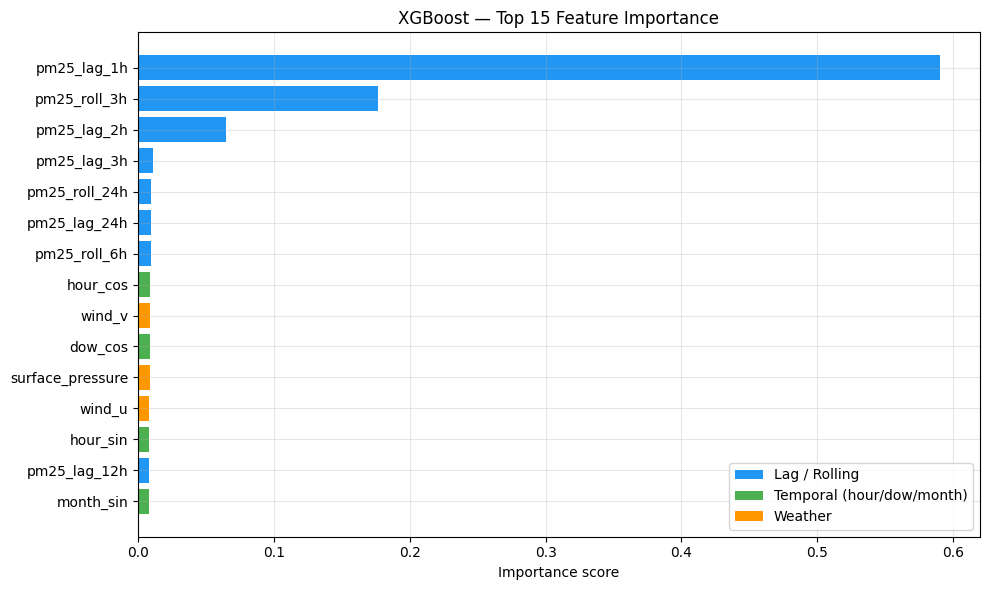

In [14]:
importances = model.feature_importances_
fi = pd.DataFrame({'feature': feature_cols, 'importance': importances})
fi = fi.sort_values('importance', ascending=False).head(15).reset_index(drop=True)

print('Top 15 features:')
print(fi.to_string(index=False))

colors = ['#2196F3' if ('lag' in f or 'roll' in f) else
          '#4CAF50' if any(w in f for w in ['hour', 'dow', 'month']) else
          '#FF9800'
          for f in fi['feature']]

plt.figure(figsize=(10, 6))
plt.barh(fi['feature'][::-1], fi['importance'][::-1], color=colors[::-1])
plt.xlabel('Importance score')
plt.title('XGBoost — Top 15 Feature Importance')

legend_elements = [
    Patch(facecolor='#2196F3', label='Lag / Rolling'),
    Patch(facecolor='#4CAF50', label='Temporal (hour/dow/month)'),
    Patch(facecolor='#FF9800', label='Weather'),
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '05_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Largest prediction errors

In [15]:
test_copy = test.copy()
test_copy['y_pred'] = y_pred_test
test_copy['error']  = np.abs(y_test - y_pred_test)

big_errors = test_copy.nlargest(10, 'error')[['datetime', 'pm25', 'y_pred', 'error']]
big_errors.columns = ['Date', 'Actual', 'Predicted', 'Abs Error']
big_errors = big_errors.round(2)

print('Top 10 largest prediction errors:')
print(big_errors.to_string(index=False))

Top 10 largest prediction errors:
                     Date  Actual  Predicted  Abs Error
2026-01-09 06:00:00+00:00  215.82 109.220001     106.60
2026-01-10 20:00:00+00:00  152.93  60.950001      91.98
2025-12-19 07:00:00+00:00  184.11 102.739998      81.37
2025-12-24 02:00:00+00:00  138.60  74.050003      64.56
2025-12-19 18:00:00+00:00  199.05 134.770004      64.28
2026-01-02 12:00:00+00:00  128.25  65.779999      62.47
2025-12-28 08:00:00+00:00  113.68  51.869999      61.81
2025-12-21 23:00:00+00:00   15.00  76.169998      61.17
2026-01-11 23:00:00+00:00   15.90  72.510002      56.61
2025-12-19 23:00:00+00:00  175.95 123.010002      52.95


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19928\420598772.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  big_errors = big_errors.round(2)


## 12. Monthly RMSE breakdown

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19928\4170749126.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  test_copy['month'] = test_copy['datetime'].dt.to_period('M')


Monthly metrics:
  month  RMSE   MAE     R2     n
2025-12 16.23 10.89 0.8409 441.0
2026-01 11.42  6.73 0.8478 744.0
2026-02  2.61  1.98 0.8808 672.0
2026-03  2.78  1.97 0.9087 744.0
2026-04  1.72  1.32 0.8936 720.0
2026-05  1.76  1.33 0.9108 744.0
2026-06  2.34  1.81 0.8910 168.0


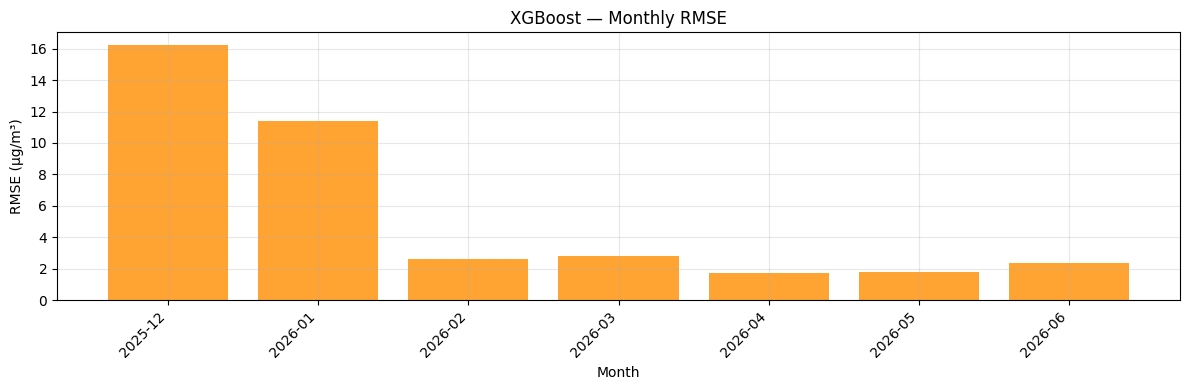

In [16]:
test_copy['month'] = test_copy['datetime'].dt.to_period('M')
monthly = test_copy.groupby('month').apply(
    lambda g: pd.Series({
        'RMSE': round(np.sqrt(mean_squared_error(g['pm25'], g['y_pred'])), 2),
        'MAE':  round(mean_absolute_error(g['pm25'], g['y_pred']), 2),
        'R2':   round(r2_score(g['pm25'], g['y_pred']), 4) if len(g) > 1 else None,
        'n':    len(g),
    })
).reset_index()

print('Monthly metrics:')
print(monthly.to_string(index=False))

plt.figure(figsize=(12, 4))
plt.bar(monthly['month'].astype(str), monthly['RMSE'], color='darkorange', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Month')
plt.ylabel('RMSE (µg/m³)')
plt.title('XGBoost — Monthly RMSE')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '06_monthly_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Save model and metrics

In [17]:
model_path = os.path.join(MODELS_DIR, 'xgboost_es.json')
model.save_model(model_path)
print(f'Model saved => {model_path}')

fi_top15 = [{'feature': r['feature'], 'importance': round(r['importance'], 6)}
             for _, r in fi.iterrows()]
fi_path = os.path.join(OUT_DIR, 'xgb_feature_importance.json')
with open(fi_path, 'w') as f:
    json.dump(fi_top15, f, indent=2)
print(f'Feature importance saved => {fi_path}')

metrics = {
    'model': 'XGBoost + EarlyStopping',
    'train': {'rmse': round(rmse_train, 4), 'mae': round(mae_train, 4), 'r2': round(r2_train, 4)},
    'test':  {'rmse': round(rmse_test,  4), 'mae': round(mae_test,  4), 'r2': round(r2_test,  4)},
    'params': {
        'n_estimators_max': 500,
        'best_iteration': model.best_iteration,
        'early_stopping_rounds': 20,
        'learning_rate': 0.05,
        'max_depth': 7,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
    },
    'train_time_sec': round(elapsed, 1),
}

metrics_path = os.path.join(OUT_DIR, 'xgb_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Metrics saved => {metrics_path}')

print('\n=== FINAL RESULTS ===')
print(f'  RMSE : {rmse_test:.3f}')
print(f'  MAE  : {mae_test:.3f}')
print(f'  R2   : {r2_test:.4f}')
print(f'  Best round: {model.best_iteration}')

Model saved => c:\Users\LENOVO\Desktop\Project 2.5\pm25_project\service1\models\xgboost_es.json
Feature importance saved => c:\Users\LENOVO\Desktop\Project 2.5\pm25_project\service1\outputs\xgb_es_analysis\xgb_feature_importance.json
Metrics saved => c:\Users\LENOVO\Desktop\Project 2.5\pm25_project\service1\outputs\xgb_es_analysis\xgb_metrics.json

=== FINAL RESULTS ===
  RMSE : 7.353
  MAE  : 3.509
  R2   : 0.9143
  Best round: 92
